In [220]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

## LIBRARY

#### Kode tersebut merupakan kode untuk mengimport library yang dibutuhkan, seperti OpenCV, Matplotlib.pyplot, dan NumPy:
- Library OpenCV digunakan untuk melakukan berbagai operasi citra seperti membaca, menampilkan, memproses, dan memodifikasi, namun pada jurnal kali ini hanya digunakan untuk membaca dan mengubah citra menjadi grayscale.
- NumPy digunakan untuk representasi citra dalam bentuk matriks array, dan pada jurnal kali ini digunakan untuk melalukan operasi pada matriks dan manipulasi piksel.
- Matplotlib digunakan untuk menampilkan citra hasil pemrosesan berbagai tahap proses

(450, 800)


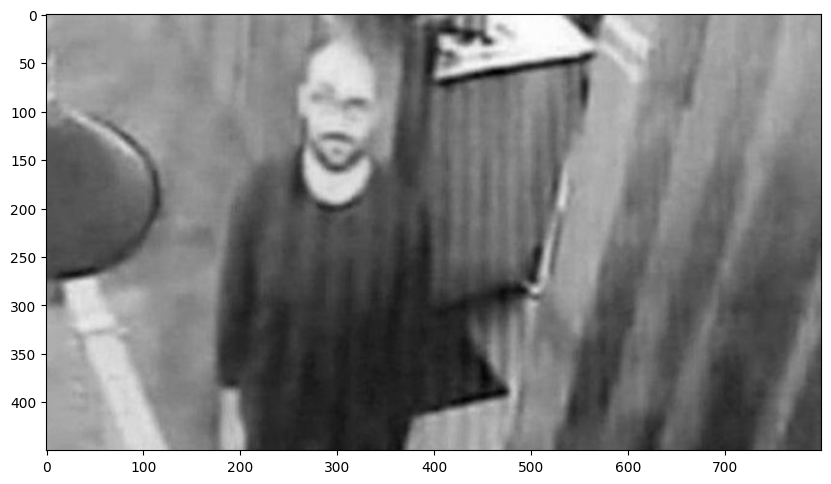

In [221]:
cctv = cv.imread('backup.jpg')
cctvG = cv.cvtColor(cctv, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 10))
plt.imshow(cctvG, cmap = 'gray')

print(cctvG.shape)

#### Membaca dan Mengubah Citra Menjadi Grayscale

Kode di atas digunakan untuk membaca citra `backup.jpg` menggunakan fungsi `cv.imread('')` yang kemudian disimpan dalam variabel `cctv`. Kemudian variabel `cctv` tersebut diubah menjadi `citra grayscale` dengan menggunakan fungsi `cv.cvtColor(, cv.COLOR_BGR2GRAY)` yang kemudian disimpan dalam variabel `cctvG`. kemudian ditampilkan menggunakan fungsi `plt.imshow`

In [222]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for val in region.ravel():
                        total += val
                    canvas[i, j] = total // area
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel().tolist()
                    values.sort()
                    n = len(values)
                    mid = n // 2
                    if n % 2 == 1:
                        median_val = values[mid]
                    else:
                        median_val = (values[mid - 1] + values[mid]) // 2
                    canvas[i, j] = median_val
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
    return canvas

#### Fungsi Filter Citra (Mean, Median, Modus)

Kode di atas merupakan fungsi `filter(img, size, mode)` yang digunakan untuk menerapkan filter pada citra grayscale. Fungsi ini menerima parameter `img` berupa citra grayscale, `size` berupa ukuran kernel (misalnya 3 untuk kernel 3x3 dan 9 untuk kernel 9x9), dan `mode` berupa jenis filter yang ingin digunakan.

Pertama, fungsi mengambil dimensi citra menggunakan `img.shape`, kemudian menghitung nilai padding dengan `size // 2` agar piksel di tepi citra tetap dapat diproses. Padding diterapkan menggunakan `np.pad()` dengan mode `'edge'` sehingga tepi citra diisi dengan nilai piksel terdekat. Sebuah kanvas kosong berukuran sama dengan citra asli dibuat menggunakan `np.zeros_like()` sebagai tempat menyimpan hasil filter.

Selanjutnya, fungsi memilih jenis filter berdasarkan nilai `mode` menggunakan blok `match-case`:

- Jika `mode='mean'`, fungsi menghitung **rata-rata** nilai piksel dalam setiap region kernel. Untuk setiap posisi piksel `(i, j)`, region di sekitarnya diambil dari citra yang telah di-padding, kemudian seluruh nilai dijumlahkan secara manual dan dibagi dengan luas area kernel (`size * size`).

- Jika `mode='median'`, fungsi menghitung **nilai tengah** dari seluruh piksel dalam region kernel. Nilai-nilai piksel diurutkan menggunakan `.sort()`, kemudian nilai median diambil dari posisi tengah. Jika jumlah elemen ganjil, diambil nilai tengahnya langsung; jika genap, diambil rata-rata dua nilai tengah.

- Jika `mode='modus'`, fungsi menghitung **nilai yang paling sering muncul** dalam region kernel. Frekuensi setiap nilai piksel dihitung menggunakan dictionary `count`, kemudian nilai dengan frekuensi tertinggi dipilih sebagai hasil filter.

Hasil dari setiap piksel yang telah difilter disimpan ke dalam `canvas[i, j]`, dan pada akhirnya fungsi mengembalikan `canvas` sebagai citra hasil filtering.

In [223]:
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
[1/10, 1/10, 1/10],
[1/10, 1/5, 1/10],
[1/10, 1/10, 1/10]
])
# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
[1/9, 1/9, 1/9],
[1/9, 8/9, 1/9],
[1/9, 1/9, 1/9]
])
 # kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
 [-1, 0, 1],
 [-2, 0, 2],
 [-1, 0, 1]
], dtype=np.float32)
 # kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
 [1, 2, 1],
 [0, 0, 0],
 [-1, -2, -1]
], dtype=np.float32)
# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
[-1, 0, 1],
[-1, 0, 1],
[-1, 0, 1]
], dtype=np.float32)
# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
[1, 1, 1],
[0, 0, 0],
[-1, -1, -1]
], dtype=np.float32)
# kernel roberts sumbu x / x-axis sobel kernel
robertsX = np.array([
[1, 0],
[0, -1]
], dtype=np.float32)
# kernel roberts sumbu y / y-axis sobel kernel
robertsY = np.array([
[0, 1],
[-1, 0]
], dtype=np.float32)

#### Kernel untuk Filtering Citra

Kode di atas mendefinisikan beberapa kernel yang digunakan untuk operasi konvolusi pada citra. Setiap kernel memiliki fungsi yang berbeda-beda, mulai dari penghalusan, penajaman, hingga deteksi tepi.

**Kernel Smoothing** didefinisikan dalam variabel `kernelSmoothing` berupa matriks 3x3 yang memberikan bobot lebih besar pada piksel pusat (`1/5`) dibandingkan piksel sekitarnya (`1/10`). Kernel ini digunakan untuk menghaluskan citra dengan cara meratakan nilai piksel berdasarkan tetangganya sehingga noise pada citra dapat berkurang.

**Kernel Sharpening** didefinisikan dalam variabel `kernelSharpening` berupa matriks 3x3 yang memberikan bobot besar pada piksel pusat (`8/9`) dan bobot kecil pada piksel sekitarnya (`1/9`). Kernel ini digunakan untuk mempertajam citra dengan cara memperkuat perbedaan nilai antar piksel sehingga detail dan tepi pada citra menjadi lebih jelas.

**Kernel Sobel** terdiri dari dua matriks 3x3 bertipe `float32`, yaitu `sobelX` untuk mendeteksi tepi pada **sumbu horizontal** dan `sobelY` untuk mendeteksi tepi pada **sumbu vertikal**. Kernel Sobel menggunakan bobot yang berbeda pada baris tengah (`-2` dan `2` untuk X, `2` dan `-2` untuk Y) sehingga lebih sensitif terhadap perubahan gradien pada arah yang dituju.

**Kernel Prewitt** juga terdiri dari dua matriks 3x3 bertipe `float32`, yaitu `prewittX` untuk mendeteksi tepi pada **sumbu horizontal** dan `prewittY` untuk mendeteksi tepi pada **sumbu vertikal**. Berbeda dengan Sobel, kernel Prewitt menggunakan bobot yang seragam (`-1`, `0`, `1`) pada setiap baris sehingga perhitungannya lebih sederhana namun kurang sensitif terhadap noise.

**Kernel Roberts** terdiri dari dua matriks 2x2 bertipe `float32`, yaitu `robertsX` dan `robertsY`. Kernel ini mendeteksi tepi secara **diagonal** menggunakan pola silang dengan nilai `1` dan `-1`. Ukurannya yang lebih kecil membuat Roberts lebih cepat secara komputasi namun lebih rentan terhadap noise dibandingkan Sobel maupun Prewitt.

In [224]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

#### Fungsi Konvolusi Citra

Kode di atas merupakan fungsi `convolution(img, kernel)` yang digunakan untuk melakukan operasi konvolusi antara citra grayscale dengan sebuah kernel. Fungsi ini menerima parameter `img` berupa citra grayscale dan `kernel` berupa matriks filter yang ingin diterapkan.

Pertama, fungsi mengambil ukuran kernel menggunakan `kernel.shape[0]`, kemudian menghitung nilai padding dengan `size // 2` agar seluruh piksel termasuk yang berada di tepi citra tetap dapat diproses. Padding diterapkan menggunakan `np.pad()` dengan mode `'constant'` sehingga tepi citra diisi dengan nilai nol. Sebuah kanvas kosong bertipe `float32` dibuat menggunakan `np.zeros_like()` sebagai tempat menyimpan hasil konvolusi.

Selanjutnya, fungsi melakukan iterasi pada setiap piksel citra menggunakan dua perulangan `for` pada sumbu `i` (tinggi) dan `j` (lebar). Untuk setiap posisi piksel `(i, j)`, diambil sebuah region dari citra yang telah di-padding dengan ukuran sesuai kernel. Operasi konvolusi dilakukan dengan mengalikan setiap elemen region dengan elemen kernel yang bersesuaian menggunakan `region * kernel`, kemudian seluruh hasilnya dijumlahkan menggunakan `np.sum()` dan disimpan ke `canvas[i, j]`.

Pada akhirnya, fungsi mengembalikan `canvas` berupa citra hasil konvolusi dalam format `float32`, yang siap digunakan untuk proses selanjutnya seperti normalisasi atau konversi kembali ke tipe `uint8`.

In [225]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

In [226]:
def edge_double_method(img, kernelx1, kernely1, kernelx2, kernely2):
    gx1 = convolution(img, kernelx1)
    gy1 = convolution(img, kernely1)
    gx2 = convolution(img, kernelx2)
    gy2 = convolution(img, kernely2)
    
    canvas = np.abs(gx1) + np.abs(gy1) + \
             np.abs(gx2) + np.abs(gy2)
    
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def edge_triple_method(img, kernelx1, kernely1, kernelx2, kernely2, kernelx3, kernely3):
    gx1 = convolution(img, kernelx1)
    gy1 = convolution(img, kernely1)
    gx2 = convolution(img, kernelx2)
    gy2 = convolution(img, kernely2)
    gx3 = convolution(img, kernelx3)
    gy3 = convolution(img, kernely3)
    
    canvas = np.abs(gx1) + np.abs(gy1) + \
             np.abs(gx2) + np.abs(gy2) + \
             np.abs(gx3) + np.abs(gy3)
    
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

#### Fungsi Deteksi Tepi (Edge Detection)

Kode di atas mendefinisikan fungsi `edge(img, kernelx, kernely)` yang digunakan untuk mendeteksi tepi pada citra grayscale menggunakan dua kernel arah, yaitu sumbu horizontal dan vertikal. Fungsi ini menerima parameter `img` berupa citra grayscale, `kernelx` berupa kernel deteksi tepi arah horizontal, dan `kernely` berupa kernel deteksi tepi arah vertikal.

Pertama, fungsi menghitung gradien horizontal `gx` dan gradien vertikal `gy` dengan memanggil fungsi `convolution()` menggunakan masing-masing kernel yang diberikan. Kedua gradien ini merepresentasikan perubahan intensitas piksel pada masing-masing arah.

Selanjutnya, dibuat kanvas kosong bertipe `float32` menggunakan `np.zeros_like()`. Kemudian magnitudo gradien dihitung dengan menjumlahkan nilai absolut dari `gx` dan `gy` menggunakan `np.abs(gx) + np.abs(gy)`. Penggunaan nilai absolut memastikan bahwa perubahan intensitas ke arah manapun tetap terhitung sebagai tepi.

Hasil magnitudo kemudian dinormalisasi ke rentang `0–255` dengan cara mengalikan setiap nilai dengan `255.0` lalu dibagi dengan nilai maksimum pada canvas menggunakan `np.max(canvas)`. Hal ini dilakukan agar hasil deteksi tepi dapat ditampilkan sebagai citra 8-bit.

Pada akhirnya, fungsi mengembalikan canvas yang telah di-clip menggunakan `np.clip()` untuk memastikan seluruh nilai berada dalam rentang `0–255`, kemudian dikonversi ke tipe `uint8` sebagai citra hasil deteksi tepi yang siap ditampilkan.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

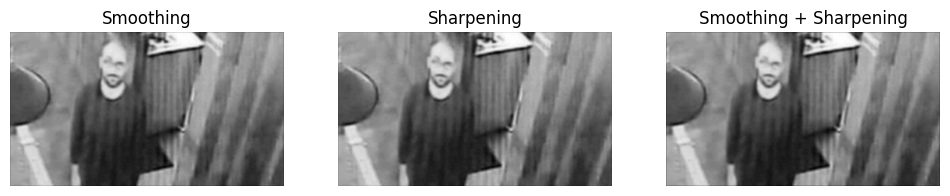

In [227]:
cctvSmoothing = convolution(cctvG, kernelSmoothing)
cctvSharpening = convolution(cctvG, kernelSharpening)
cctvKomb = convolution(cctvG, kernelSmoothing)
cctvKomb = convolution(cctvKomb, kernelSharpening)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(cctvSmoothing, cmap = 'gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cctvSharpening, cmap = 'gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cctvKomb, cmap = 'gray')
plt.title('Smoothing + Sharpening')
plt.axis('off')

#### Penerapan Kernel Smoothing, Sharpening, dan Kombinasi

Kode di atas digunakan untuk menerapkan operasi konvolusi pada citra grayscale `cctvG` menggunakan kernel yang telah didefinisikan sebelumnya, kemudian menampilkan hasilnya secara berdampingan.

Pertama, fungsi `convolution()` dipanggil tiga kali untuk menghasilkan tiga variasi citra. Variabel `cctvSmoothing` menyimpan hasil konvolusi `cctvG` dengan `kernelSmoothing` untuk menghaluskan citra. Variabel `cctvSharpening` menyimpan hasil konvolusi `cctvG` dengan `kernelSharpening` untuk mempertajam citra. Variabel `cctvKomb` menyimpan hasil kombinasi kedua kernel, yaitu dengan menerapkan `kernelSmoothing` terlebih dahulu pada `cctvG`, kemudian hasilnya dikonvolusi kembali dengan `kernelSharpening` sehingga citra dihaluskan sekaligus dipertajam secara berurutan.

Selanjutnya, ketiga hasil citra tersebut ditampilkan secara berdampingan menggunakan `plt.figure()` dengan ukuran `(12, 6)`. Setiap citra ditampilkan pada subplot yang berbeda menggunakan `plt.subplot(1, 3, n)` dengan keterangan judul masing-masing, yaitu `'Smoothing'`, `'Sharpening'`, dan `'Smoothing + Sharpening'`. Parameter `cmap='gray'` digunakan agar citra ditampilkan dalam skala abu-abu, dan `plt.axis('off')` digunakan untuk menyembunyikan sumbu pada setiap subplot.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

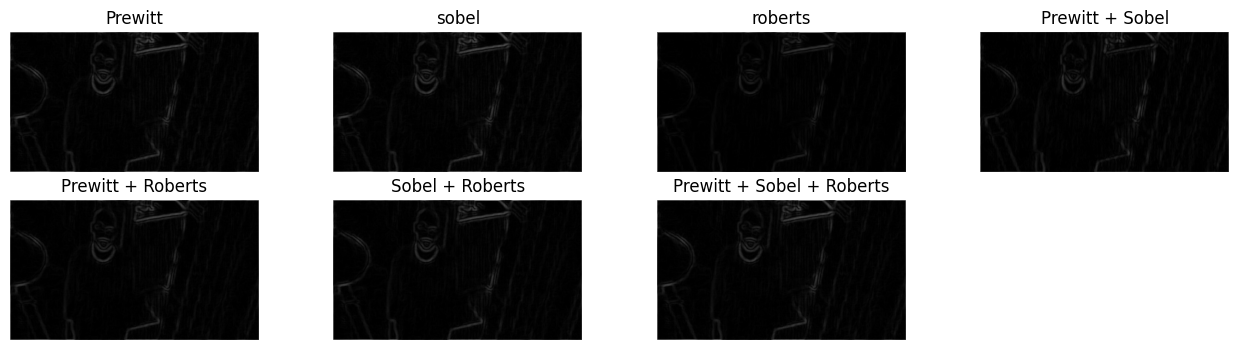

In [228]:
prewitt = edge(cctvKomb, prewittX, prewittY)
sobel = edge(cctvKomb, sobelX, sobelY)
roberts = edge(cctvKomb, robertsX, robertsY)
preSob = edge_double_method(cctvKomb, prewittX, prewittY, sobelX, sobelX)
preRob = edge_double_method(cctvKomb, prewittX, prewittY, robertsX, robertsY)
sobRob = edge_double_method(cctvKomb, sobelX, sobelY, robertsX, robertsY)
preSobRob = edge_triple_method(cctvKomb, prewittX, prewittY, sobelX, sobelY, robertsX, robertsY)

plt.figure(figsize=(16, 4))

plt.subplot(2, 4, 1)
plt.imshow(prewitt, cmap = 'gray')
plt.title('Prewitt')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(sobel, cmap = 'gray')
plt.title('sobel')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(roberts, cmap = 'gray')
plt.title('roberts')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(preSob, cmap = 'gray')
plt.title('Prewitt + Sobel')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(preRob, cmap = 'gray')
plt.title('Prewitt + Roberts')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(sobRob, cmap = 'gray')
plt.title('Sobel + Roberts')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(preSobRob, cmap = 'gray')
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')

#### Penerapan dan Kombinasi Deteksi Tepi (Edge Detection)

Kode di atas digunakan untuk menerapkan berbagai metode deteksi tepi pada citra `cctvKomb` yang merupakan hasil kombinasi smoothing dan sharpening sebelumnya, kemudian menampilkan seluruh hasilnya secara berdampingan.

Pertama, fungsi `edge()` dipanggil tiga kali untuk menghasilkan deteksi tepi menggunakan masing-masing metode. Variabel `prewitt` menyimpan hasil deteksi tepi menggunakan kernel Prewitt, variabel `sobel` menggunakan kernel Sobel, dan variabel `roberts` menggunakan kernel Roberts.

Selanjutnya, dibuat empat variasi kombinasi dari ketiga hasil deteksi tepi tersebut. Variabel `preSob` menyimpan rata-rata dari `prewitt` dan `sobel`, variabel `preRob` menyimpan rata-rata dari `prewitt` dan `roberts`, variabel `sobRob` menyimpan rata-rata dari `sobel` dan `roberts`, dan variabel `preSobRob` menyimpan rata-rata dari ketiga metode sekaligus yaitu `prewitt`, `sobel`, dan `roberts`. Operasi rata-rata dilakukan agar hasil kombinasi tetap berada dalam rentang nilai yang sesuai untuk ditampilkan sebagai citra.

Ketujuh hasil citra tersebut kemudian ditampilkan menggunakan `plt.figure()` dengan ukuran `(16, 4)` dalam susunan grid `2x4` menggunakan `plt.subplot(2, 4, n)`. Setiap subplot diberi judul sesuai metode yang digunakan, ditampilkan dalam skala abu-abu dengan `cmap='gray'`, dan sumbu disembunyikan menggunakan `plt.axis('off')`.

In [229]:
def thresholding (image, threshold):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype = image.dtype)
    for i in range(h):
        for j in range(w):
            if image[i, j] > threshold:
                hasil[i, j] = 255
            else:
                hasil[i, j] = 0
    return hasil

#### Fungsi Thresholding Citra

Kode di atas mendefinisikan fungsi `thresholding(image, threshold)` yang digunakan untuk mengubah citra grayscale menjadi citra biner berdasarkan nilai ambang batas tertentu. Fungsi ini menerima parameter `image` berupa citra grayscale dan `threshold` berupa nilai ambang batas yang digunakan sebagai acuan pemisahan piksel.

Pertama, fungsi mengambil dimensi citra menggunakan `image.shape` yang disimpan dalam variabel `h` (tinggi) dan `w` (lebar). Kemudian dibuat sebuah matriks kosong `hasil` berukuran sama dengan citra asli menggunakan `np.zeros()` dengan tipe data yang sama seperti citra input.

Selanjutnya, fungsi melakukan iterasi pada setiap piksel citra menggunakan dua perulangan `for` pada sumbu `i` (tinggi) dan `j` (lebar). Untuk setiap piksel `(i, j)`, nilai piksel dibandingkan dengan nilai `threshold`. Jika nilai piksel lebih besar dari `threshold`, maka piksel tersebut ditetapkan menjadi `255` (putih); sebaliknya jika nilai piksel kurang dari atau sama dengan `threshold`, piksel ditetapkan menjadi `0` (hitam).

Pada akhirnya, fungsi mengembalikan matriks `hasil` berupa citra biner yang hanya memiliki dua nilai piksel yaitu `0` dan `255`, yang siap digunakan untuk proses selanjutnya seperti deteksi objek maupun segmentasi citra.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

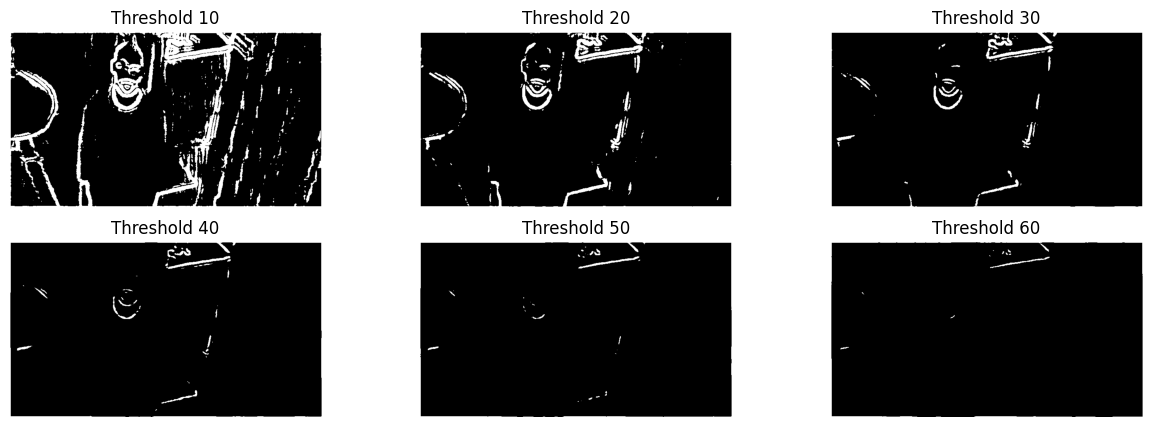

In [247]:
cctvT10 = thresholding(prewitt, 10)
cctvT20 = thresholding(prewitt, 20)
cctvT30 = thresholding(prewitt, 30)
cctvT40 = thresholding(prewitt, 40)
cctvT50 = thresholding(prewitt, 50)
cctvT60 = thresholding(prewitt, 60)

plt.figure(figsize=(15, 5))

plt.subplot(2, 3, 1)
plt.imshow(cctvT10, cmap = 'gray')
plt.title('Threshold 10')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(cctvT20, cmap = 'gray')
plt.title('Threshold 20')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(cctvT30, cmap = 'gray')
plt.title('Threshold 30')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(cctvT40, cmap = 'gray')
plt.title('Threshold 40')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(cctvT50, cmap = 'gray')
plt.title('Threshold 50')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cctvT60, cmap = 'gray')
plt.title('Threshold 60')
plt.axis('off')

#### Penerapan Thresholding dengan Berbagai Nilai Ambang Batas

Kode di atas digunakan untuk menerapkan fungsi `thresholding()` pada citra `prewitt` yang merupakan hasil kombinasi deteksi tepi Prewitt dan Sobel, dengan enam nilai ambang batas yang berbeda-beda untuk membandingkan pengaruhnya terhadap hasil segmentasi citra.

Fungsi `thresholding()` dipanggil sebanyak enam kali dengan nilai threshold yang berbeda, yaitu `10`, `20`, `30`, `40`, `50`, dan `60`. Setiap hasil disimpan dalam variabel masing-masing, yaitu `cctvT10` hingga `cctvT60`. Semakin kecil nilai threshold, semakin banyak piksel yang dianggap sebagai tepi sehingga citra hasil akan lebih terang dan penuh detail; sebaliknya semakin besar nilai threshold, semakin sedikit piksel yang lolos sehingga hanya tepi yang paling kuat saja yang tertampil.

Keenam hasil citra biner tersebut kemudian ditampilkan secara berdampingan menggunakan `plt.figure()` dengan ukuran `(15, 5)` dalam susunan grid `2x3` menggunakan `plt.subplot(2, 3, n)`. Setiap subplot diberi judul sesuai nilai threshold yang digunakan, ditampilkan dalam skala abu-abu dengan `cmap='gray'`, dan sumbu disembunyikan menggunakan `plt.axis('off')`.

# HIGHLIGHT

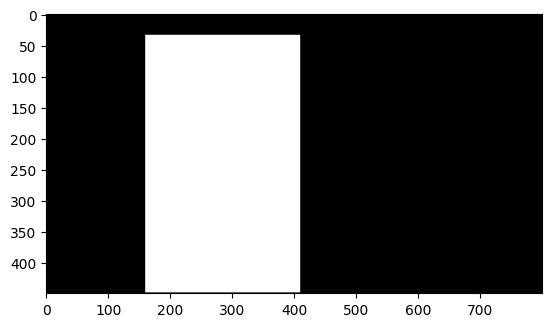

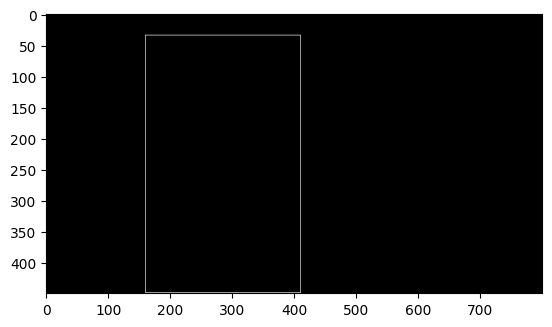

In [231]:
h, w = cctvKomb.shape

masker = np.zeros((h, w))
maskerDT = np.zeros((h, w))

for i in range(35, 449):
    for j in range(160, 410):
        masker[i, j] = 255

for i in range(35, 449 + 1):
    for j in range(160, 410 + 1):
        if i == 35 or i == 449 or j == 160 or j == 410:
            maskerDT[i, j] = 255

plt.imshow(masker, cmap = 'gray')
plt.show()

plt.imshow(maskerDT, cmap = 'gray')
plt.show()

#### Pembuatan Masker Area Orang

Kode di atas digunakan untuk membuat dua jenis masker berbentuk persegi panjang secara manual pada citra `cctvKomb`, yaitu masker solid dan masker garis tepi (outline), yang merepresentasikan area di mana objek orang berada.

Pertama, dimensi citra diambil menggunakan `cctvKomb.shape` yang disimpan dalam variabel `h` (tinggi) dan `w` (lebar). Dua buah matriks kosong berukuran sama dengan citra dibuat menggunakan `np.zeros()`, yaitu `masker` untuk masker solid dan `maskerDT` untuk masker garis tepi.

Selanjutnya, `masker` dibuat dengan mengisi seluruh piksel yang berada di dalam rentang baris `35` hingga `449` dan kolom `160` hingga `410` dengan nilai `255` menggunakan dua perulangan `for`. Hasilnya berupa area persegi panjang berwarna putih yang menutupi seluruh area orang pada citra.

Sementara itu, `maskerDT` dibuat dengan hanya mengisi piksel yang berada tepat pada **batas tepi** persegi panjang, yaitu piksel yang memenuhi kondisi `i == 35`, `i == 449`, `j == 160`, atau `j == 410`. Hasilnya berupa garis tepi persegi panjang berwarna putih yang merepresentasikan bounding box area orang tanpa mengisi bagian dalamnya.

Kedua masker kemudian ditampilkan secara terpisah menggunakan `plt.imshow()` dengan `cmap='gray'` untuk memperlihatkan perbedaan antara masker solid dan masker garis tepi.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

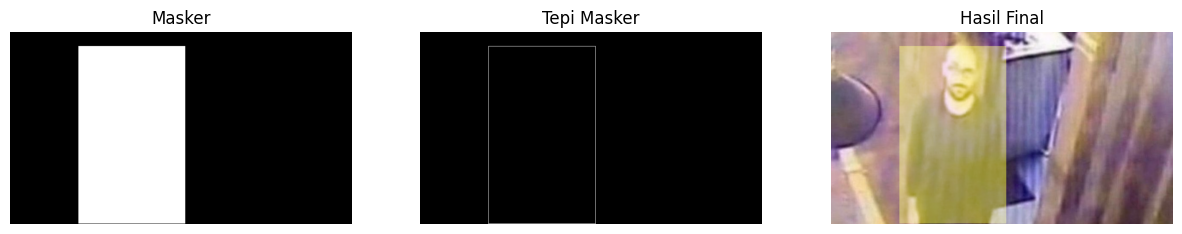

In [232]:
cctvBaru = cv.imread('backup.jpg') 
cctvRGB = cv.cvtColor(cctvBaru, cv.COLOR_BGR2RGB)
cctvFinal = cctvRGB.copy()

for i in range(h):
    for j in range(w):
        if masker[i, j] == 255:
            cctvFinal[i, j, 0] = (cctvFinal[i, j, 0] * 0.5 + 255 * 0.5)
            cctvFinal[i, j, 1] = (cctvFinal[i, j, 1] * 0.5 + 255 * 0.5)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(masker, cmap='gray')
plt.title("Masker")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(maskerDT, cmap = 'gray')
plt.title("Tepi Masker")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cctvFinal)
plt.title("Hasil Final")
plt.axis('off')

#### Penerapan Masker dan Highlight pada Citra Asli

Kode di atas digunakan untuk menerapkan masker yang telah dibuat sebelumnya pada citra asli `backup.jpg` dengan memberikan efek highlight berwarna kuning pada area orang yang terdeteksi.

Pertama, citra asli dibaca kembali menggunakan `cv.imread('backup.jpg')` dan dikonversi dari format BGR ke RGB menggunakan `cv.cvtColor()` dengan parameter `cv.COLOR_BGR2RGB` agar warna tampil dengan benar saat ditampilkan menggunakan matplotlib. Salinan citra RGB disimpan dalam variabel `cctvFinal` menggunakan `.copy()` sebagai kanvas yang akan dimodifikasi.

Selanjutnya, fungsi melakukan iterasi pada setiap piksel citra menggunakan dua perulangan `for`. Untuk setiap piksel `(i, j)` yang nilai maskernya sama dengan `255`, dilakukan modifikasi pada channel warna merah (`[i, j, 0]`) dan channel warna hijau (`[i, j, 1]`) dengan mencampurkan nilai asli piksel dengan nilai maksimum `255` menggunakan bobot masing-masing `0.5`. Pencampuran kedua channel ini menghasilkan warna kuning pada area yang di-highlight, karena warna kuning dalam model RGB terbentuk dari kombinasi merah dan hijau yang tinggi. Channel biru (`[i, j, 2]`) tidak dimodifikasi agar warna kuning tetap terjaga.

Ketiga citra kemudian ditampilkan secara berdampingan menggunakan `plt.figure()` dengan ukuran `(15, 5)` dalam susunan grid `1x3`. Subplot pertama menampilkan `masker` solid, subplot kedua menampilkan `maskerDT` berupa garis tepi, dan subplot ketiga menampilkan `cctvFinal` sebagai hasil akhir citra dengan highlight kuning pada area orang.

# DAVID

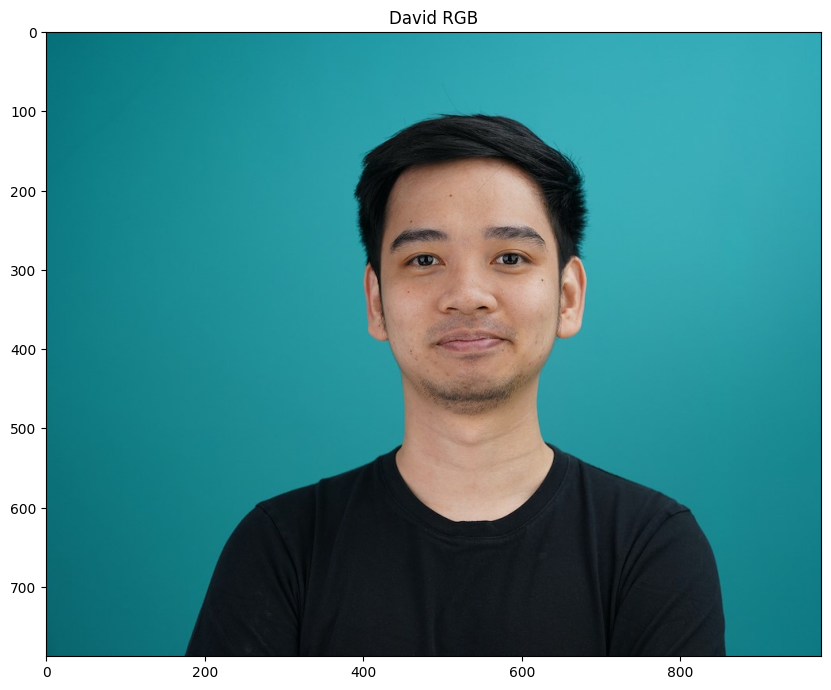

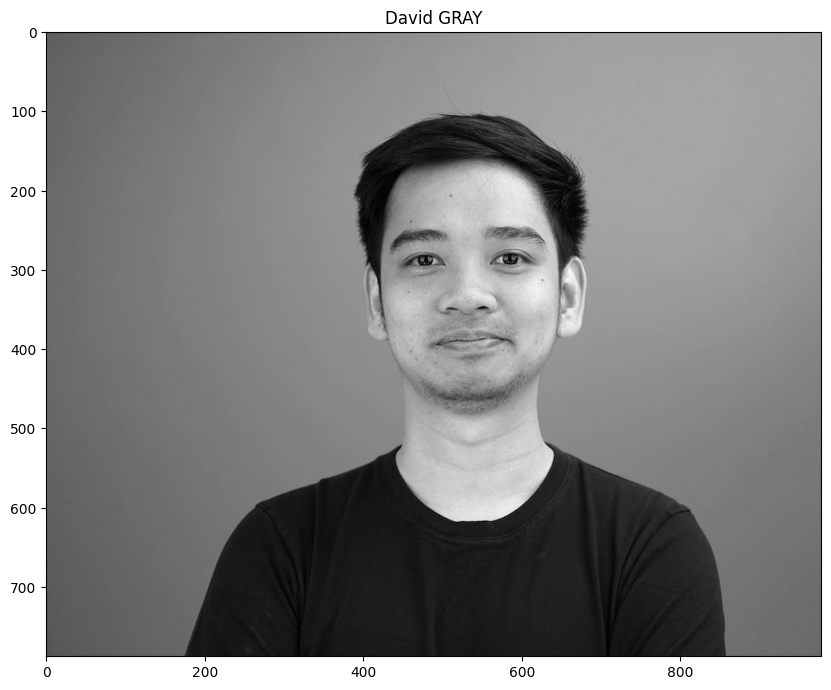

In [233]:
david = cv.imread('david.jpg')
davidRGB = cv.cvtColor(david, cv.COLOR_BGR2RGB)
davidG = cv.cvtColor(david, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 10))
plt.title('David RGB')
plt.imshow(davidRGB, cmap = 'gray')
plt.show()

plt.figure(figsize=(10, 10))
plt.title('David GRAY')
plt.imshow(davidG, cmap = 'gray')
plt.show()

#### Membaca dan Mengubah Citra David Menjadi Grayscale

Kode di atas digunakan untuk membaca citra `david.jpg` dan mengubahnya menjadi dua format tampilan yang berbeda, yaitu RGB dan grayscale.

Pertama, citra dibaca menggunakan `cv.imread('david.jpg')` yang disimpan dalam variabel `david`. Kemudian citra dikonversi dari format BGR ke RGB menggunakan `cv.cvtColor()` dengan parameter `cv.COLOR_BGR2RGB` dan disimpan dalam variabel `davidRGB` agar warna tampil dengan benar saat ditampilkan menggunakan matplotlib. Selanjutnya, citra juga dikonversi dari format BGR ke grayscale menggunakan `cv.cvtColor()` dengan parameter `cv.COLOR_BGR2GRAY` dan disimpan dalam variabel `davidG`.

Kedua citra kemudian ditampilkan secara terpisah menggunakan `plt.figure()` dengan ukuran `(10, 10)`. Citra pertama menampilkan `davidRGB` dengan judul `'David RGB'` dalam format warna asli, dan citra kedua menampilkan `davidG` dengan judul `'David GRAY'` dalam skala abu-abu menggunakan `cmap='gray'`.

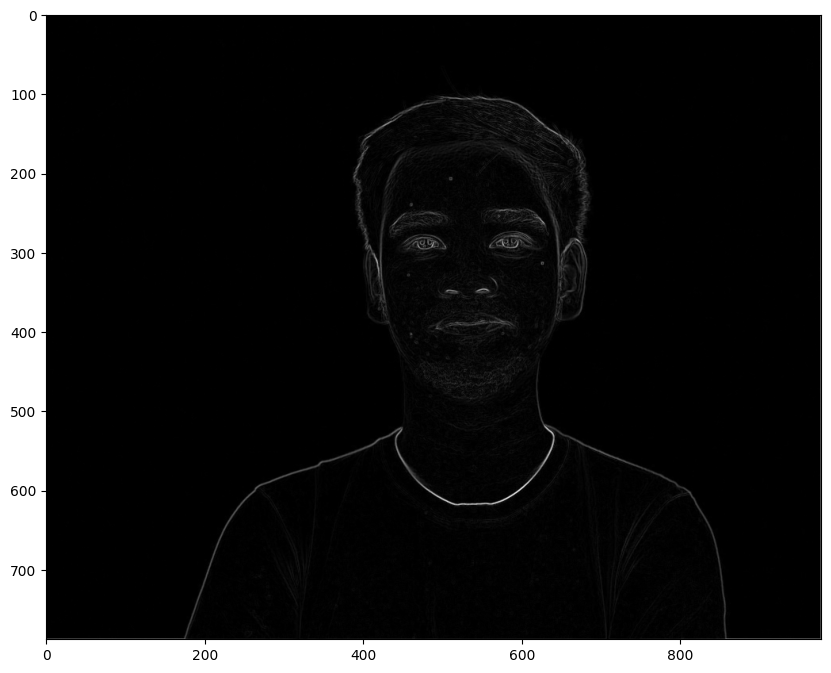

In [234]:
davidDT = edge(davidG, sobelX, sobelY)

plt.figure(figsize=(10, 10))
plt.imshow(davidDT, cmap = 'gray')

#### Deteksi Tepi pada Citra David Menggunakan Sobel

Kode di atas digunakan untuk mendeteksi tepi pada citra grayscale `davidG` menggunakan metode Sobel, kemudian menampilkan hasilnya.

Fungsi `edge()` dipanggil dengan parameter `davidG` sebagai citra input, serta `sobelX` dan `sobelY` sebagai kernel deteksi tepi pada sumbu horizontal dan vertikal. Hasil deteksi tepi disimpan dalam variabel `davidDT` yang merepresentasikan magnitudo gradien dari citra `davidG`.

Hasil deteksi tepi kemudian ditampilkan menggunakan `plt.figure()` dengan ukuran `(10, 10)` dan `plt.imshow()` dengan `cmap='gray'` agar tepi yang terdeteksi tampil dalam skala abu-abu.

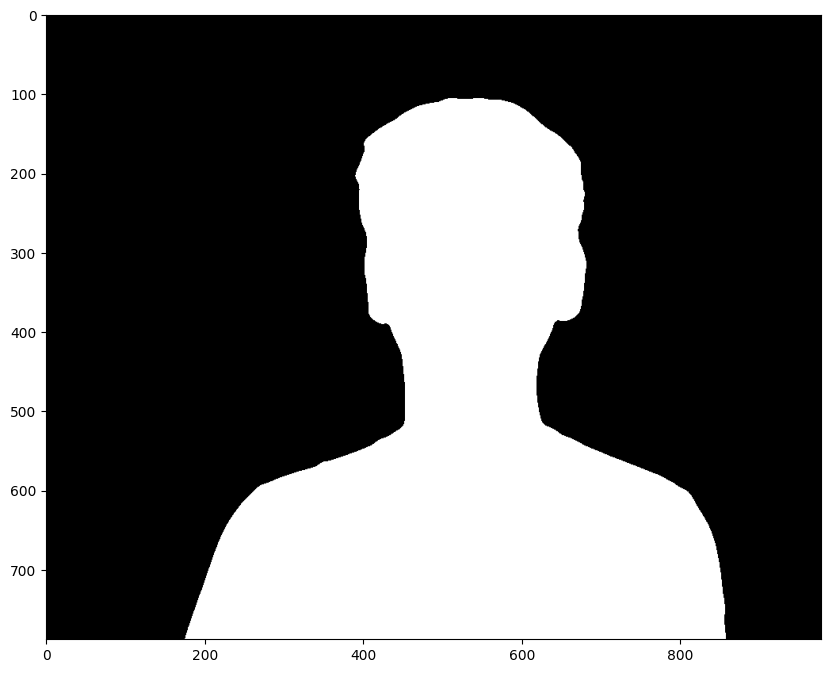

In [235]:
h, w = davidG.shape
maskerDavid = np.zeros((h, w), dtype=np.uint8)
for i in range(h):
    for j in range(w):
        r = float(davidRGB[i, j, 0])
        g = float(davidRGB[i, j, 1])
        b = float(davidRGB[i, j, 2])
        if g > r and b > r and g > 80 and b > 80:
            maskerDavid[i, j] = 0
        else:
            maskerDavid[i, j] = 255

maskerDavid = filter(maskerDavid, 9, 'median')

plt.figure(figsize=(10, 10))
plt.imshow(maskerDavid, cmap = 'gray')

#### Pembuatan Masker pada Citra David Berbasis Warna

Kode di atas digunakan untuk membuat masker pada citra `davidRGB` secara otomatis dengan mendeteksi area background berdasarkan karakteristik warna hijau-biru, kemudian menghaluskan hasil masker menggunakan filter median.

Pertama, dimensi citra grayscale `davidG` diambil menggunakan `.shape` dan disimpan dalam variabel `h` dan `w`. Kemudian dibuat matriks kosong `maskerDavid` berukuran sama dengan citra menggunakan `np.zeros()` bertipe `uint8` sebagai tempat menyimpan hasil masker.

Selanjutnya, fungsi melakukan iterasi pada setiap piksel citra menggunakan dua perulangan `for`. Untuk setiap piksel `(i, j)`, nilai channel merah (`r`), hijau (`g`), dan biru (`b`) diambil dari `davidRGB` dan dikonversi ke tipe `float` agar perbandingan nilainya lebih akurat. Piksel yang memenuhi kondisi `g > r`, `b > r`, `g > 80`, dan `b > 80` diklasifikasikan sebagai background (area hijau-kebiruan) dan diberi nilai `0` (hitam). Piksel yang tidak memenuhi kondisi tersebut diklasifikasikan sebagai foreground (area orang) dan diberi nilai `255` (putih).

Setelah masker terbentuk, fungsi `filter()` dipanggil dengan ukuran kernel `9` dan mode `'median'` untuk menghaluskan masker dan mengurangi noise yang muncul akibat deteksi warna yang tidak sempurna. Hasil masker yang telah dihaluskan kemudian ditampilkan menggunakan `plt.figure()` dengan ukuran `(10, 10)` dan `cmap='gray'`.

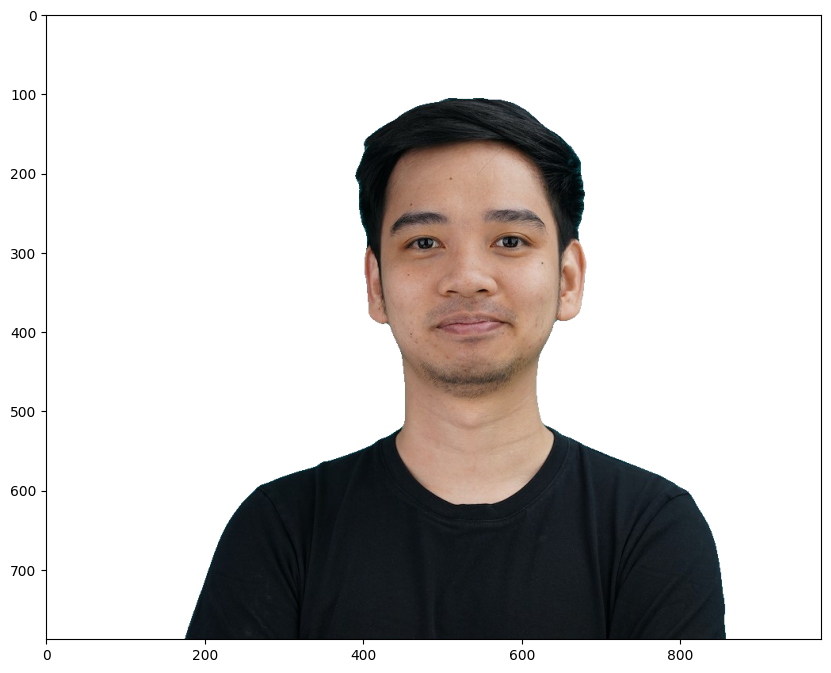

In [236]:
d4vd = np.zeros((h, w, 3), dtype=np.uint8)
for i in range (h):
    for j in range (w):
        if maskerDavid[i, j] == 255:
            d4vd[i, j] = davidRGB[i, j]
        else:
            d4vd[i, j] = 255

plt.figure(figsize=(10, 10))
plt.imshow(d4vd)

#### Penerapan Masker pada Citra David

Kode di atas digunakan untuk menerapkan `maskerDavid` pada citra `davidRGB` sehingga hanya area foreground (orang) yang ditampilkan, sementara area background digantikan dengan warna putih.

Pertama, dibuat sebuah matriks kosong `d4vd` berukuran `(h, w, 3)` bertipe `uint8` menggunakan `np.zeros()` sebagai kanvas hasil yang akan menampung citra akhir dengan tiga channel warna RGB.

Selanjutnya, fungsi melakukan iterasi pada setiap piksel menggunakan dua perulangan `for`. Untuk setiap piksel `(i, j)`, nilai masker diperiksa. Jika `maskerDavid[i, j] == 255`, piksel tersebut merupakan area foreground sehingga nilai warna asli dari `davidRGB[i, j]` disalin ke `d4vd[i, j]`. Sebaliknya jika nilai masker adalah `0`, piksel tersebut merupakan area background sehingga `d4vd[i, j]` diisi dengan nilai `255` yang merepresentasikan warna putih pada ketiga channel RGB.

Hasil citra `d4vd` kemudian ditampilkan menggunakan `plt.figure()` dengan ukuran `(10, 10)` dan `plt.imshow()` tanpa parameter `cmap` karena citra yang ditampilkan merupakan citra berwarna RGB.

(np.float64(-0.5), np.float64(977.5), np.float64(787.5), np.float64(-0.5))

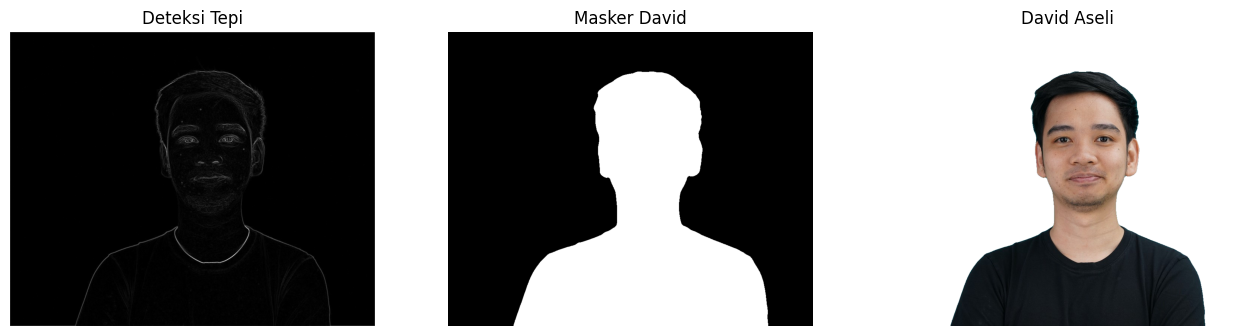

In [237]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
plt.imshow(davidDT, cmap = 'gray')
plt.title('Deteksi Tepi')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(maskerDavid, cmap = 'gray')
plt.title('Masker David')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(d4vd)
plt.title('David Aseli')
plt.axis('off')

#### Visualisasi Hasil Deteksi Tepi, Masker, dan Citra Akhir

Kode di atas digunakan untuk menampilkan tiga hasil pemrosesan citra David secara berdampingan, yaitu hasil deteksi tepi, masker, dan citra akhir setelah penerapan masker.

Ketiga citra ditampilkan menggunakan `plt.figure()` dengan ukuran `(16, 8)` dalam susunan grid `1x3` menggunakan `plt.subplot(1, 3, n)`. Subplot pertama menampilkan `davidDT` berupa hasil deteksi tepi menggunakan Sobel dengan judul `'Deteksi Tepi'` dalam skala abu-abu. Subplot kedua menampilkan `maskerDavid` berupa masker biner hasil deteksi warna background dengan judul `'Masker David'` dalam skala abu-abu. Subplot ketiga menampilkan `d4vd` berupa citra David dengan background digantikan warna putih dengan judul `'David Aseli'` dalam format warna RGB. Sumbu pada setiap subplot disembunyikan menggunakan `plt.axis('off')`.

## ANALISIS ALUR HIGHLIGHT SILUET ORANG PADA CITRA CCTV

1. **Konversi gambar ke _grayscale_**

   Citra CCTV `backup.jpg` dibaca menggunakan `cv.imread()`, lalu diubah menjadi citra _grayscale_ menggunakan `cv.cvtColor()` dengan parameter `cv.COLOR_BGR2GRAY`. Proses ini menghilangkan informasi warna dan hanya menyisakan intensitas terang-gelap agar memudahkan proses operasi pada citra selanjutnya.

2. **Penghalusan dan penajaman citra dengan konvolusi**

   Citra _grayscale_ diproses menggunakan fungsi `convolution()` dengan tiga variasi kernel. Pertama, `kernelSmoothing` diterapkan untuk menghaluskan citra dan mengurangi _noise_. Kedua, `kernelSharpening` diterapkan untuk mempertajam detail citra. Ketiga, kombinasi keduanya diterapkan secara berurutan — citra dihaluskan terlebih dahulu, kemudian dipertajam — menghasilkan `cctvKomb` yang menjadi dasar proses selanjutnya.

3. **Deteksi tepi dengan berbagai operator**

   Deteksi tepi dilakukan pada `cctvKomb` menggunakan tiga operator, yaitu Prewitt, Sobel, dan Roberts, melalui fungsi `edge()`. Selain itu, dibuat pula kombinasi antar operator menggunakan `edge_double_method()` dan `edge_triple_method()` untuk menghasilkan deteksi tepi yang lebih lengkap. Seluruh hasil ditampilkan secara berdampingan untuk dibandingkan.

4. **_Thresholding_ hasil deteksi tepi**

   Hasil deteksi tepi Prewitt kemudian di-_thresholding_ dengan enam nilai ambang batas yang berbeda, yaitu `10`, `20`, `30`, `40`, `50`, dan `60`. Semakin kecil nilai _threshold_, semakin banyak piksel yang dianggap sebagai tepi sehingga citra lebih terang dan penuh detail. Sebaliknya, semakin besar nilai _threshold_, hanya tepi yang paling kuat saja yang tertampil.

5. **Pembuatan masker area orang**

   Masker dibuat secara manual menggunakan dua perulangan `for` pada koordinat yang telah ditentukan, yaitu baris `35–449` dan kolom `160–410`. Dibuat dua jenis masker, yaitu `masker` berupa area solid berwarna putih yang menutupi seluruh area orang, dan `maskerDT` berupa garis tepi persegi panjang (_bounding box_) yang hanya mengisi piksel pada batas tepi area tersebut.

6. **Penerapan _highlight_ kuning pada citra asli**

   Citra asli `backup.jpg` dibaca kembali dan dikonversi ke format RGB. Kemudian, untuk setiap piksel yang berada pada area masker, nilai _channel_ merah dan hijau dicampurkan dengan nilai maksimum `255` menggunakan bobot masing-masing `0.5`. Pencampuran kedua _channel_ ini menghasilkan warna kuning pada area yang di-_highlight_, karena warna kuning dalam model RGB terbentuk dari kombinasi merah dan hijau yang tinggi. Hasil akhirnya ditampilkan berdampingan bersama `masker` dan `maskerDT`.

7. **Konversi citra David ke _grayscale_**

   Citra `david.jpg` dibaca dan dikonversi ke dua format, yaitu RGB (`davidRGB`) dan _grayscale_ (`davidG`). Kedua format ditampilkan secara terpisah untuk memperlihatkan perbedaan antara citra berwarna dan citra _grayscale_.

8. **Deteksi tepi pada citra David**

   Deteksi tepi dilakukan pada `davidG` menggunakan operator Sobel melalui fungsi `edge()`. Hasilnya disimpan dalam variabel `davidDT` yang merepresentasikan magnitudo gradien dari citra David.

9. **Pembuatan masker David berbasis warna**

   Masker dibuat secara otomatis dengan mendeteksi area _background_ berdasarkan karakteristik warna hijau-kebiruan. Setiap piksel yang memenuhi kondisi `g > r`, `b > r`, `g > 80`, dan `b > 80` diklasifikasikan sebagai _background_ dan diberi nilai `0`, sedangkan piksel lainnya diklasifikasikan sebagai _foreground_ (orang) dan diberi nilai `255`. Masker kemudian dihaluskan menggunakan filter median berukuran `9x9` untuk mengurangi _noise_ pada tepi masker.

10. **Ekstraksi objek dari _background_**

    Masker yang telah dihaluskan diterapkan pada `davidRGB` untuk memisahkan objek orang dari _background_. Piksel yang berada pada area masker (`255`) mempertahankan warna aslinya, sedangkan piksel di luar masker (`0`) digantikan dengan warna putih. Hasil akhirnya adalah citra David dengan _background_ putih yang bersih.

11. **Visualisasi hasil akhir**

    Ketiga hasil pemrosesan citra David ditampilkan secara berdampingan, yaitu `davidDT` berupa hasil deteksi tepi, `maskerDavid` berupa masker biner hasil deteksi warna, dan `d4vd` berupa citra David dengan _background_ putih sebagai hasil akhir dari seluruh proses.

## KESIMPULAN

Pada praktikum ini, telah dilakukan proses highlight siluet orang pada citra CCTV dan ekstraksi objek pada citra David.

Untuk citra CCTV, proses diawali dengan konversi citra ke `grayscale`, dilanjutkan dengan penghalusan dan penajaman menggunakan konvolusi kernel, kemudian deteksi tepi menggunakan operator Prewitt, Sobel, dan Roberts beserta kombinasinya. Masker area orang dibuat secara manual berdasarkan koordinat yang ditentukan, kemudian diterapkan pada citra asli untuk menghasilkan efek `highlight` berwarna kuning pada area orang yang terdeteksi.

Untuk citra David, masker dibuat secara otomatis berbasis deteksi warna `background` pada ruang warna RGB. Piksel yang memiliki dominansi warna hijau-kebiruan diklasifikasikan sebagai `background` dan dihapus dari masker, sementara sisanya dipertahankan sebagai `foreground`. Hasilnya adalah citra David yang berhasil diekstraksi dari `background` dengan bersih.

Dari kedua pendekatan tersebut, dapat disimpulkan bahwa pembuatan masker secara manual memberikan kontrol yang lebih presisi namun bergantung pada koordinat yang ditentukan secara spesifik, sedangkan pembuatan masker berbasis warna lebih fleksibel dan otomatis namun sangat bergantung pada karakteristik warna citra. Kombinasi teknik konvolusi, deteksi tepi, `thresholding`, dan `masking` terbukti mampu menghasilkan highlight siluet orang yang cukup akurat.